In [1]:
# Cell 1 — Load model, data, and feature names
import numpy as np
import pickle
import matplotlib.pyplot as plt
import shap
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Load best model artifact
with open('../model/artifacts/churn_model.pkl', 'rb') as f:
    model_artifact = pickle.load(f)

best_model       = model_artifact['model']
optimal_threshold = model_artifact['optimal_threshold']
model_name       = model_artifact['model_name']

# Load data
X_test  = np.load('../model/artifacts/X_test_fe.npy',  allow_pickle=True).astype(float)
y_test  = np.load('../model/artifacts/y_test_fe.npy',  allow_pickle=True).astype(int)
X_train = np.load('../model/artifacts/X_train_fe.npy', allow_pickle=True).astype(float)

# Load feature names
with open('../model/artifacts/feature_columns_fe.pkl', 'rb') as f:
    feature_names = pickle.load(f)

# Wrap in DataFrame — SHAP plots look much better with named columns
X_test_df  = pd.DataFrame(X_test,  columns=feature_names)
X_train_df = pd.DataFrame(X_train, columns=feature_names)

print(f"Model loaded    : {model_name}")
print(f"Threshold       : {optimal_threshold}")
print(f"X_test shape    : {X_test_df.shape}")
print(f"Features        : {feature_names}")

Model loaded    : Random Forest (Tuned)
Threshold       : 0.5499999999999998
X_test shape    : (1407, 31)
Features        : ['tenure', 'MonthlyCharges', 'tenure_monthly_ratio', 'avg_monthly_per_service', 'service_count', 'contract_tenure_interact', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'InternetService_0', 'InternetService_DSL', 'InternetService_Fiber optic', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'is_long_term_contract', 'is_senior_alone', 'is_fiber_high_bill', 'no_support_services']


In [10]:
# Cell 2 — Final Fix
explainer = shap.TreeExplainer(best_model)

shap_values = explainer.shap_values(X_test_df)

print(f"Raw shape : {shap_values.shape}")  # (1407, 31, 2)

# Take only class 1 (churn) — index [:, :, 1]
shap_values_churn = shap_values[:, :, 1]

print(f"Fixed shape : {shap_values_churn.shape}")  # should be (1407, 31)
print("✅ Correct" if shap_values_churn.ndim == 2 else "❌ Still wrong")

# Probabilities for later cells
y_prob = best_model.predict_proba(X_test_df)[:, 1]

Raw shape : (1407, 31, 2)
Fixed shape : (1407, 31)
✅ Correct


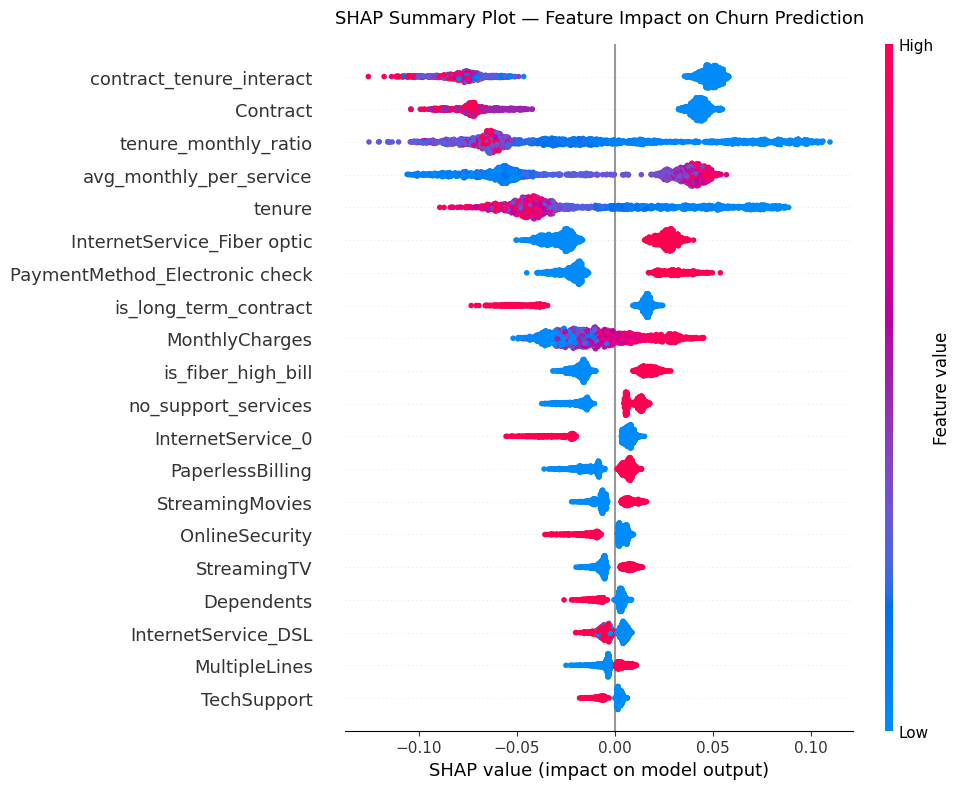

Saved: shap_summary.png


In [11]:
# Cell 3 — SHAP Summary Plot
# Why this plot:
#   - Shows GLOBAL feature importance across all test customers
#   - Each dot = one customer
#   - X position = SHAP value (impact on churn probability)
#   - Color = feature value (red=high, blue=low)
#   - Features ranked top to bottom by importance
# This is the #1 plot interviewers ask about

plt.figure()
shap.summary_plot(
    shap_values_churn,
    X_test_df,
    feature_names=feature_names,
    show=False,
    plot_size=(10, 8)
)
plt.title('SHAP Summary Plot — Feature Impact on Churn Prediction', 
          fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('../model/artifacts/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_summary.png")

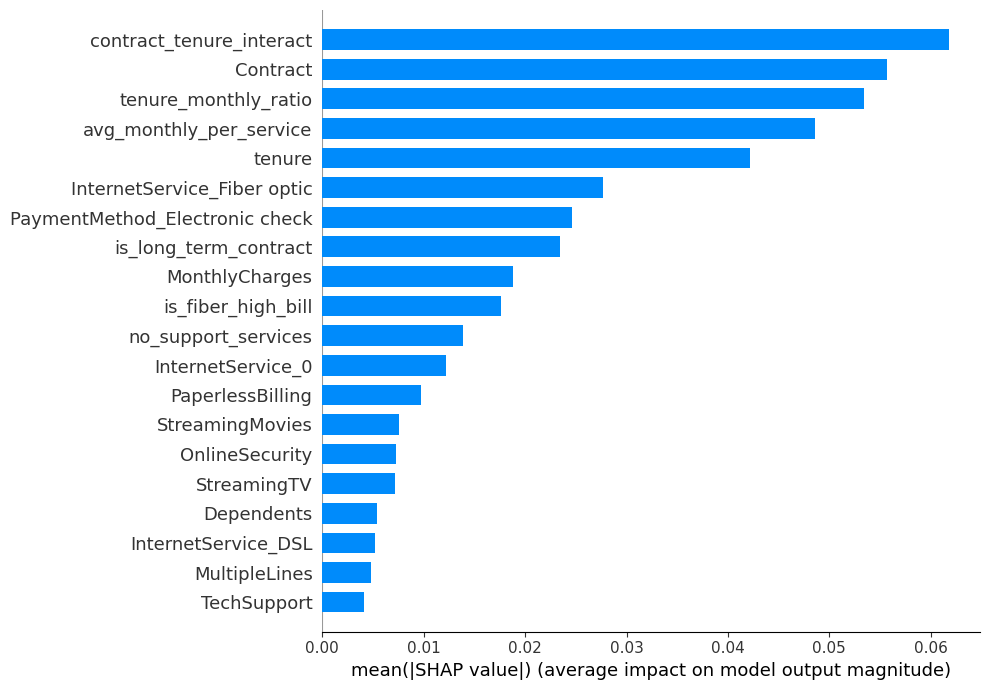

In [ ]:
# Cell 4 — Fixed
shap.summary_plot(
    shap_values_churn,
    X_test_df,
    feature_names=feature_nam es,
    plot_type='bar',        # ← this is the key line
    show=False,
    plot_size=(10, 7)
)

Customer index     : 211
Churn probability  : 0.9379
Actual label       : Stay
Base value : 0.49970312863465055


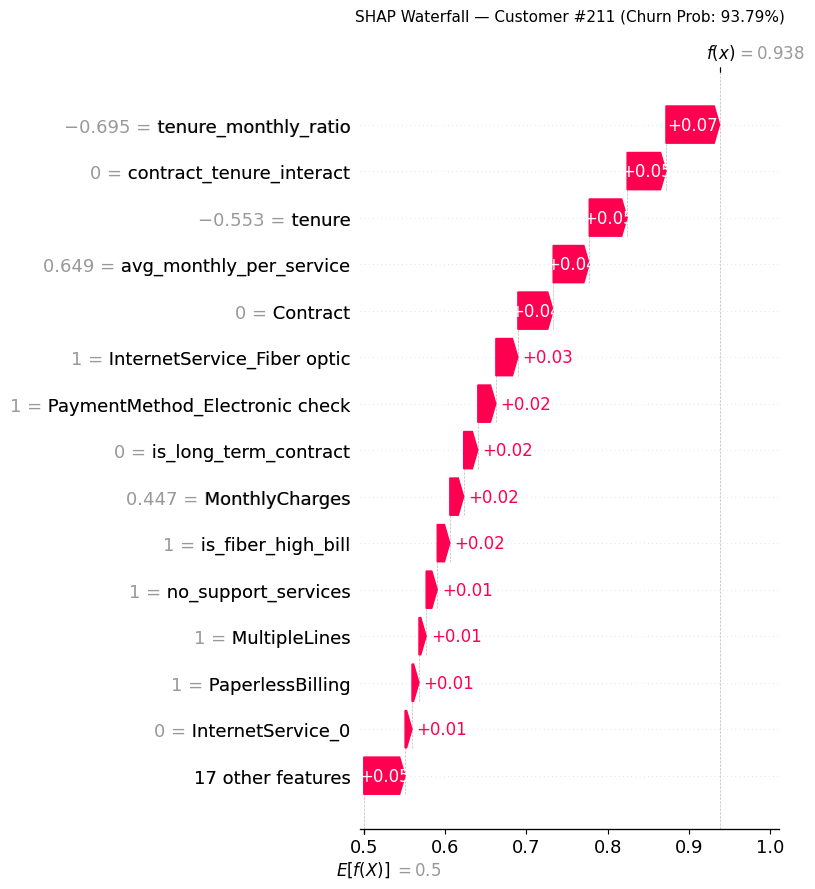

Saved: shap_waterfall_churn.png


In [16]:
# Cell 5 — Waterfall Plot FIXED

churn_idx = np.argsort(y_prob)[::-1][0]

print(f"Customer index     : {churn_idx}")
print(f"Churn probability  : {y_prob[churn_idx]:.4f}")
print(f"Actual label       : {'Churn' if y_test[churn_idx]==1 else 'Stay'}")

# Fix — extract base_value correctly
base_val = explainer.expected_value

# Handle all possible shapes
if isinstance(base_val, (list, np.ndarray)):
    if np.array(base_val).ndim == 0:
        base_val = float(base_val)
    else:
        base_val = float(np.array(base_val).flatten()[-1])  # take class 1
else:
    base_val = float(base_val)

print(f"Base value : {base_val}")  # should be a single float like 0.26

explanation = shap.Explanation(
    values        = shap_values_churn[churn_idx],
    base_values   = base_val,                      # ← flat scalar now
    data          = X_test_df.iloc[churn_idx].values,
    feature_names = feature_names
)

shap.plots.waterfall(explanation, max_display=15, show=False)
plt.title(f'SHAP Waterfall — Customer #{churn_idx} '
          f'(Churn Prob: {y_prob[churn_idx]:.2%})', fontsize=11, pad=15)
plt.tight_layout()
plt.savefig('../model/artifacts/shap_waterfall_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_waterfall_churn.png")

Customer index     : 653
Churn probability  : 0.0038
Actual label       : Stay


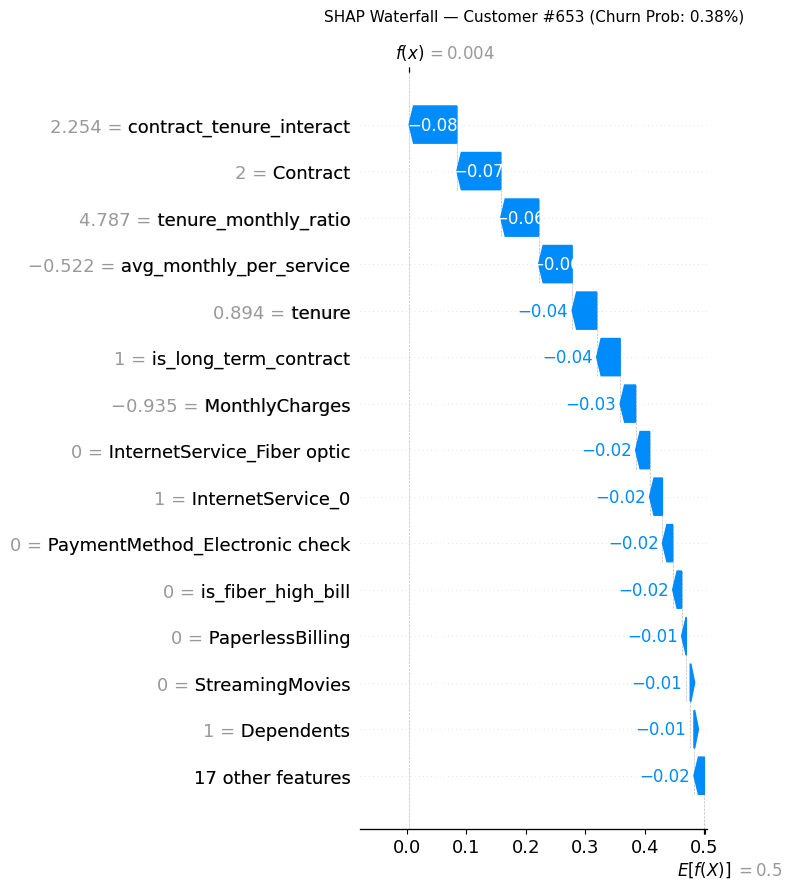

Saved: shap_waterfall_stay.png


In [17]:
# Cell 6 — Waterfall for a customer predicted to stay
# Why: Showing both sides makes the explanation complete.
# You can demo this in an interview: "here's why we flag this person,
# here's why we don't flag that person."

stay_idx = np.argsort(y_prob)[0]  # lowest churn probability

print(f"Customer index     : {stay_idx}")
print(f"Churn probability  : {y_prob[stay_idx]:.4f}")
print(f"Actual label       : {'Churn' if y_test[stay_idx]==1 else 'Stay'}")

explanation_stay = shap.Explanation(
    values        = shap_values_churn[stay_idx],
    base_values   = base_val,          # ← same base_val from Cell 5
    data          = X_test_df.iloc[stay_idx].values,
    feature_names = feature_names
)

plt.figure()
shap.waterfall_plot(explanation_stay, show=False, max_display=15)
plt.title(f'SHAP Waterfall — Customer #{stay_idx} '
          f'(Churn Prob: {y_prob[stay_idx]:.2%})', fontsize=11, pad=15)
plt.tight_layout()
plt.savefig('../model/artifacts/shap_waterfall_stay.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_waterfall_stay.png")

In [ ]:
# ## SHAP Business Interpretation

# ### How to read the Summary Plot
# - **Features at the top** = most influential on churn prediction
# - **Red dots pushed right** = high feature value → increases churn probability
# - **Blue dots pushed right** = low feature value → increases churn probability
# - **Dots near zero** = that feature barely mattered for that customer

# ### Expected findings from Telco churn data

# | Feature | Expected SHAP pattern | Business meaning |
# |---|---|---|
# | tenure | Blue (low tenure) → right | New customers churn more |
# | Contract | Blue (month-to-month) → right | No lock-in = easy to leave |
# | MonthlyCharges | Red (high bill) → right | Expensive plans drive churn |
# | no_support_services | Red → right | No security/support = unhappy |
# | is_fiber_high_bill | Red → right | Fiber + high bill = at-risk |
# | contract_tenure_interact | Strong signal | Long contract + long tenure = loyal |

# ### Actionable recommendations
# 1. **Target new customers (low tenure)** with onboarding offers in month 1-3
# 2. **Incentivise contract upgrades** from month-to-month to annual
# 3. **Bundle TechSupport + OnlineSecurity** for fiber optic customers
# 4. **Flag senior customers living alone** (is_senior_alone) for personal outreach

In [18]:
# Cell 8 — Save SHAP explainer for API
# Why: Recomputing SHAP values per request in the API is slow.
# Instead we save the explainer — API loads it and calls
# explainer.shap_values(single_customer) in ~milliseconds.

with open('../model/artifacts/shap_explainer.pkl', 'wb') as f:
    pickle.dump(explainer, f)

print("✅ Saved: model/artifacts/shap_explainer.pkl")
print("\nAll SHAP artifacts saved:")
print("  shap_explainer.pkl       ← API will load this")
print("  shap_summary.png         ← for report/README")
print("  shap_bar.png             ← for slides")
print("  shap_waterfall_churn.png ← demo: at-risk customer")
print("  shap_waterfall_stay.png  ← demo: safe customer")

print("\n✅ 05_shap.ipynb complete")
print("Next → api/main.py (FastAPI backend)")

✅ Saved: model/artifacts/shap_explainer.pkl

All SHAP artifacts saved:
  shap_explainer.pkl       ← API will load this
  shap_summary.png         ← for report/README
  shap_bar.png             ← for slides
  shap_waterfall_churn.png ← demo: at-risk customer
  shap_waterfall_stay.png  ← demo: safe customer

✅ 05_shap.ipynb complete
Next → api/main.py (FastAPI backend)


In [19]:
# Quick verify all artifacts exist
import os

artifacts = [
    'churn_model.pkl',
    'shap_explainer.pkl',
    'shap_summary.png',
    'shap_bar.png',
    'shap_waterfall_churn.png',
    'shap_waterfall_stay.png'
]

for f in artifacts:
    path = f'../model/artifacts/{f}'
    status = "✅" if os.path.exists(path) else "❌ MISSING"
    print(f"{status} {f}")

✅ churn_model.pkl
✅ shap_explainer.pkl
✅ shap_summary.png
✅ shap_bar.png
✅ shap_waterfall_churn.png
✅ shap_waterfall_stay.png
